<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


/tmp/ipykernel_1284/1900307046.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Industry', order=df['Industry'].value_counts().index, palette='viridis')

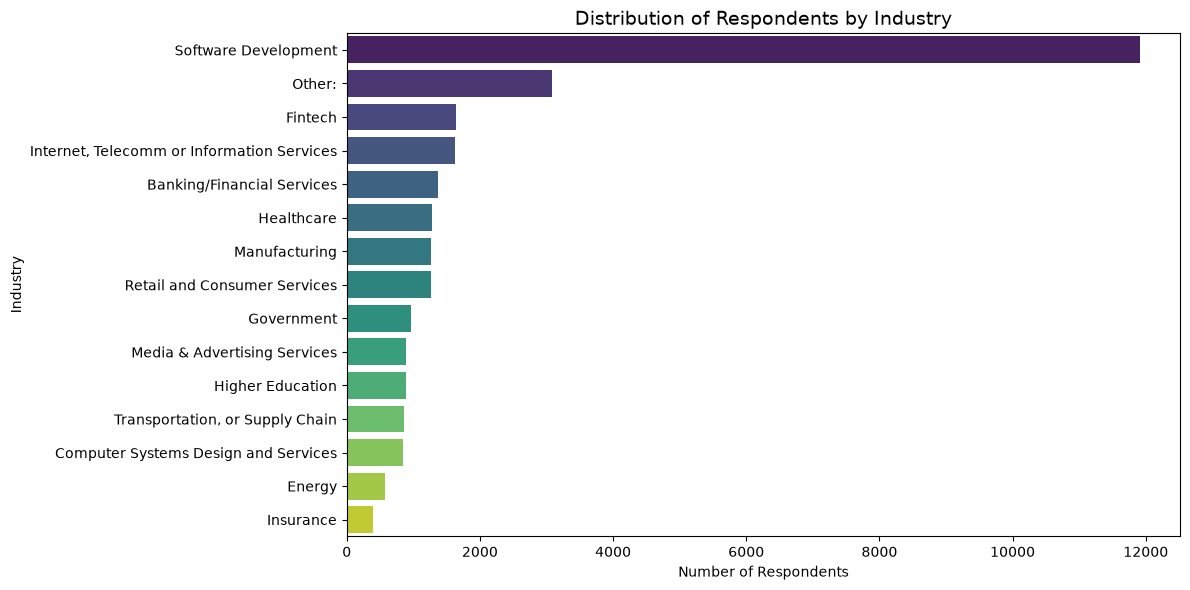

Примечание: График показывает, какие отрасли наиболее популярны среди участников опроса.

In [3]:
plt.figure(figsize=(12, 6))
# Считаем количество респондентов в каждой индустрии и строим график
sns.countplot(data=df, y='Industry', order=df['Industry'].value_counts().index, palette='viridis')

plt.title('Distribution of Respondents by Industry', fontsize=14)
plt.xlabel('Number of Respondents')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

print("Примечание: График показывает, какие отрасли наиболее популярны среди участников опроса.")

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [4]:
# 1. Заполним случайные пропуски в зарплатах медианой, чтобы код не выдавал ошибку
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].median())

# 2. Считаем базовые статистики
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print(f"Средняя зарплата (Mean): {mean_comp:.2f}")
print(f"Медианная зарплата (Median): {median_comp:.2f}")
print(f"Стандартное отклонение (Std Dev): {std_comp:.2f}\n")

# 3. Определяем порог в 3 стандартных отклонения выше среднего
upper_threshold = mean_comp + (3 * std_comp)
print(f"Порог для определения выбросов (+3 сигмы): {upper_threshold:.2f}")

# 4. Находим респондентов с зарплатой выше этого порога
high_outliers = df[df['ConvertedCompYearly'] > upper_threshold]
print(f"Количество найденных экстремально высоких выбросов: {len(high_outliers)}")

Средняя зарплата (Mean): 72576.36
Медианная зарплата (Median): 65000.00
Стандартное отклонение (Std Dev): 112220.68

Порог для определения выбросов (+3 сигмы): 409238.40
Количество найденных экстремально высоких выбросов: 194

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Нижняя граница (Lower Bound): 65000.00
Верхняя граница (Upper Bound): 65000.00
Количество выбросов по методу IQR: 23398


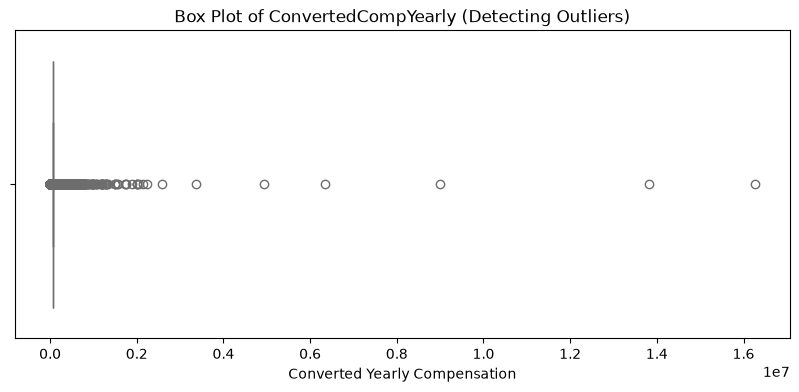

In [5]:
# 1. Вычисляем первый (Q1) и третий (Q3) квартили
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

# 2. Вычисляем межквартильный размах (IQR)
IQR = Q3 - Q1

# 3. Определяем границы для поиска выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Нижняя граница (Lower Bound): {lower_bound:.2f}")
print(f"Верхняя граница (Upper Bound): {upper_bound:.2f}")

# 4. Подсчитываем количество выбросов
outliers_iqr = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]
print(f"Количество выбросов по методу IQR: {len(outliers_iqr)}\n")

# 5. Визуализация с помощью Box plot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['ConvertedCompYearly'], color='salmon')
plt.title('Box Plot of ConvertedCompYearly (Detecting Outliers)')
plt.xlabel('Converted Yearly Compensation')
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [6]:
# 1. Считаем границы IQR заново, чтобы исключить влияние прошлых ячеек
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Создаем новый датафрейм, исключая строки с выбросами
df_clean = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)].copy()

# 3. Валидация размера нового датафрейма
print(f"Размер исходного датафрейма (с выбросами): {df.shape}")
print(f"Размер нового датафрейма (без выбросов):  {df_clean.shape}")
print(f"Удалено строк-выбросов: {df.shape[0] - df_clean.shape[0]}")


Размер исходного датафрейма (с выбросами): (65437, 114)
Размер нового датафрейма (без выбросов):  (42039, 114)
Удалено строк-выбросов: 23398

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


Матрица корреляции:
                     Age_Numeric  ConvertedCompYearly   WorkExp
Age_Numeric             1.000000                  NaN  0.854377
ConvertedCompYearly          NaN                  NaN       NaN
WorkExp                 0.854377                  NaN  1.000000

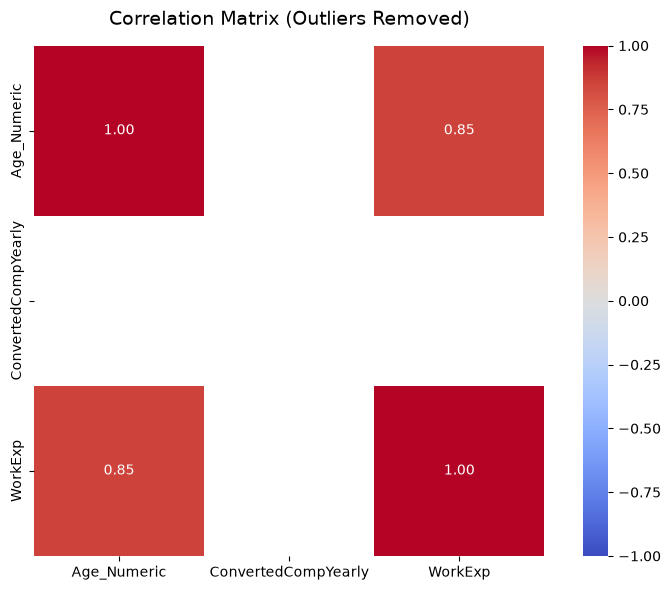

In [7]:
# 1. Маппинг столбца Age в числовые значения (приблизительное среднее значение для каждого диапазона)
# Примечание: Проверьте значения с помощью df['Age'].unique(), если категории отличаются
age_mapping = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 68
}
df_clean['Age_Numeric'] = df_clean['Age'].map(age_mapping)

# 2. Выбираем числовые колонки для анализа корреляции (включая очищенный возраст и компенсацию)
# Вы можете добавить другие числовые колонки из вашего датасета (например, 'YearsCode', 'WorkExp')
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Age_Numeric' not in numerical_cols and 'Age_Numeric' in df_clean.columns:
    numerical_cols.append('Age_Numeric')

# Ограничимся основными интересными признаками, если колонок слишком много
cols_to_corr = [col for col in ['Age_Numeric', 'ConvertedCompYearly', 'YearsCodePro_Num', 'WorkExp'] if col in df_clean.columns]
if len(cols_to_corr) < 2:  # Если специфичных колонок не нашлось, берем просто все доступные числовые
    cols_to_corr = numerical_cols[:5]

# 3. Вычисляем матрицу корреляции Пирсона
corr_matrix = df_clean[cols_to_corr].corr()
print("Матрица корреляции:")
print(corr_matrix)

# 4. Визуализация матрицы корреляции с помощью Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix (Outliers Removed)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
